In [2]:
## importing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


## libraries for preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split




In [3]:
## Load data
df = pd.read_csv("artifacts/train_data.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,master's degree,standard,none,62,70,75
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83
2,female,group D,some college,free/reduced,none,79,89,86
3,male,group C,master's degree,free/reduced,none,61,67,66
4,male,group E,high school,standard,none,73,64,57


In [4]:
df["overall_score"] = df["math score"] + df["reading score"] + df["writing score"]

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,female,group D,master's degree,standard,none,62,70,75,207
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83,232
2,female,group D,some college,free/reduced,none,79,89,86,254
3,male,group C,master's degree,free/reduced,none,61,67,66,194
4,male,group E,high school,standard,none,73,64,57,194


In [6]:
df.gender.value_counts()

gender
female    421
male      379
Name: count, dtype: int64

In [7]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    260
group D    202
group B    153
group E    116
group A     69
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
## one hot encoding helps to encode nominal categorical variables into numerical variables. It creates new columns for each category and assigns a value of 1 or 0 to indicate the presence or absence of that category in the original data.
cat_one = ["gender", "lunch", "test preparation course"]
ohe = OneHotEncoder( drop="first")
for i in cat_one:
    df[i] = ohe.fit_transform(df[[i]]).toarray()

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,group D,master's degree,1.0,1.0,62,70,75,207
1,0.0,group C,bachelor's degree,0.0,0.0,66,83,83,232
2,0.0,group D,some college,0.0,1.0,79,89,86,254
3,1.0,group C,master's degree,0.0,1.0,61,67,66,194
4,1.0,group E,high school,1.0,1.0,73,64,57,194


In [11]:
## label encoding helps to encode ordinal categorical variables into numerical variables. It assigns a unique integer to each category based on the order of the categories in the original data.
cat_label = ["race/ethnicity", "parental level of education"]
enco = LabelEncoder()
for i in cat_label:
    df[i] = enco.fit_transform(df[i])


In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,3,3,1.0,1.0,62,70,75,207
1,0.0,2,1,0.0,0.0,66,83,83,232
2,0.0,3,4,0.0,1.0,79,89,86,254
3,1.0,2,3,0.0,1.0,61,67,66,194
4,1.0,4,2,1.0,1.0,73,64,57,194


In [13]:
x= df.drop(columns=["overall_score"])
y = df["overall_score"]

In [14]:
from sklearn.preprocessing  import MinMaxScaler

In [15]:
## Normalize 
normal = MinMaxScaler()
x = normal.fit_transform(x)

In [16]:
## Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
## model building
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

## model evaluation
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 5.918350055330119e-27
R-squared: 1.0


In [18]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_test))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_test))

R2 score for train data:  1.0
R2 score for test data:  0.9886264404745165
Mean squared error for train data:  0.0
Mean squared error for test data:  20.7625


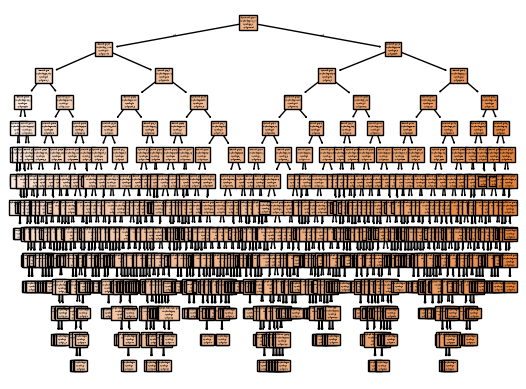

In [19]:
plot_tree(model, feature_names=df.drop(columns=["overall_score"]).columns, filled=True)
plt.show()

In [20]:
## hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = { "ccp_alpha": [0.1, 1, 10, 100],
                    "min_samples_split": [2, 5, 10], 
                            "min_samples_leaf": [1, 2, 4],
                            "max_depth": [None, 10, 20, 30]}
for i in param_grid:
    print(i, ":", param_grid[i])
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
    grid_search.fit(x_train, y_train)
    print("Best parameters: ", grid_search.best_params_)
    best_model = grid_search.best_estimator_
    y_pred_train = best_model.predict(x_train)
    y_pred_test = best_model.predict(x_test)
    print("R2 score for train data: ", r2_score(y_train, y_pred_train))
    print("R2 score for test data: ", r2_score(y_test, y_pred_test))
    print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
    print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_test))



ccp_alpha : [0.1, 1, 10, 100]
Best parameters:  {'ccp_alpha': 0.1, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data:  0.9966840112910937
R2 score for test data:  0.9865999379461211
Mean squared error for train data:  5.917306326486014
Mean squared error for test data:  24.46189231878435
min_samples_split : [2, 5, 10]
Best parameters:  {'ccp_alpha': 0.1, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data:  0.9966950560952091
R2 score for test data:  0.9845944656558819
Mean squared error for train data:  5.897597125097125
Mean squared error for test data:  28.12289381376892
min_samples_leaf : [1, 2, 4]
Best parameters:  {'ccp_alpha': 0.1, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data:  0.9966840112910937
R2 score for test data:  0.9838776520253057
Mean squared error for train data:  5.917306326486014
Mean squared error for test data:  29.43144132446617
max_depth : [No

In [21]:
from sklearn.tree import DecisionTreeRegressor

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = { "ccp_alpha" : randint(0, 100),
                "min_samples_split" : randint(2, 10),
                "min_samples_leaf" : randint(1, 4),
                "max_depth" : [None, 10, 20, 30]}
dtree = DecisionTreeRegressor()
random_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)
random_search.fit(x_train, y_train)
print("Best parameters: ", random_search.best_params_)
best_model = random_search.best_estimator_
y_pred_train = best_model.predict(x_train)  
y_pred_test = best_model.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_test))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_test))


Best parameters:  {'ccp_alpha': 1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data:  0.9856458687452252
R2 score for test data:  0.9746251092658131
Mean squared error for train data:  25.614620296190417
Mean squared error for test data:  46.32201270746523


In [23]:
# Best parameters:  {'ccp_alpha': 0.1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
dtree_final = DecisionTreeRegressor(ccp_alpha=0.1, max_depth=30, min_samples_leaf=1, min_samples_split=2)
dtree_final.fit(x_train, y_train)
y_pred_train = dtree_final.predict(x_train)
y_pred_final = dtree_final.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_final))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_final))

R2 score for train data:  0.9966950560952091
R2 score for test data:  0.9861582444979243
Mean squared error for train data:  5.897597125097125
Mean squared error for test data:  25.26820631376892
